# Retail Inventory Optimization & Supply Chain Analytics

**Author:** Sumersing Patil | Data Analyst
**Stack:** Python (Pandas, NumPy, Matplotlib, SciPy), MySQL, Tableau/Excel

---

## The problem

A retail chain running 25 stores, 8 warehouses, and 20 suppliers has been dealing with stockouts, cash tied up in excess inventory, inconsistent supplier deliveries, and reorder decisions made on gut feel rather than data. This notebook works through the raw transaction history to figure out where things are actually breaking down and what to do about it.

## What this covers

1. Assess and clean the raw data (with a full audit trail)
2. Calculate the core KPIs — revenue, turnover, fill rate, stockout rate
3. Rank products, stores, suppliers, and categories
4. Classify inventory with ABC/XYZ to flag dead stock and fast movers
5. Look at seasonal and promotional effects on revenue
6. Estimate how much revenue stockouts are actually costing
7. Generate reorder recommendations
8. Export clean, dashboard-ready datasets

## Dataset

~50,300 raw transactions at the daily store-product level, Jan 2021 – Dec 2024. 410 products across 6 categories, 25 stores, 8 warehouses, 20 suppliers.

## Project layout

```
Retail Inventory & Supply Chain Performance Analytics/
├── data/                              raw + processed CSVs
├── SQL/                               schema, views, business queries
├── Mysql_data_loader.py               CSV → MySQL loader
├── export_datasets.py                 MySQL views → CSV exporter
├── Retail_Inventory_Analytics.ipynb   this notebook
├── Clean Data/                        exports from this notebook
├── SQL_data/                          exports from the MySQL views
├── README.md
└── requirements.txt
```

## Why this matters

- Fewer stockouts on the products/stores that actually drive revenue
- Less cash sitting in dead stock
- Real visibility into which suppliers are reliable and which aren't
- Reorder points based on demand data instead of intuition
- A KPI dashboard leadership can check without pinging me for numbers

# 1. Setup & Configuration

In [1]:
# 1. Setup & Configuration

# Standard Library
import warnings
from pathlib import Path

# Data Analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Statistics
from scipy import stats

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Project Directories
DATA_DIR = Path('data')
EXPORT_DIR = Path('exports')
DATA_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Load Raw Dataset
sales_df = pd.read_csv(DATA_DIR / 'fact_sales_inventory_RAW.csv')

print('=' * 60)
print('Retail Sales Inventory Dataset — Raw')
print('=' * 60)
print(f'Rows    : {sales_df.shape[0]:,}')
print(f'Columns : {sales_df.shape[1]}')
print(f'Date range : {sales_df["date"].min()} → {sales_df["date"].max()}')

display(sales_df.head())

Retail Sales Inventory Dataset — Raw
Rows    : 50,301
Columns : 24
Date range : 01-01-2021 → 31-12-2024


,date,store_id,product_id,warehouse_id,supplier_id,units_sold,inventory_level,units_ordered,units_received,delivery_delay_days,stockout_flag,revenue,unit_price_txn,discount_pct,holiday_promo_flag,weather,season,festival_season_flag,back_to_school_flag,promo_type,customer_segment,returned_units,refund_amount,return_reason
0,04-07-2023,S025,CLO-P0011,W07,SUP06,9.00,168.00,0,0,0.00,0,5230.71,581.19,0,0,Storm,Monsoon,0,0,NaN,wholesale,0,0.00,NaN
1,27-12-2022,S006,FUR-P0038,W02,SUP12,3.00,190.00,0,0,0.00,0,55086.21,18362.07,15,1,Cold,Winter,1,0,Festival Sale,retail,0,0.00,NaN
2,2023-03-07,S021,CLO-P0019,W02,SUP05,18.00,117.00,0,0,0.00,0,9166.50,509.25,0,0,Cloudy,Summer,0,1,NaN,Wholesale,0,0.00,NaN
3,28-09-2024,S014,KIT-P0010,W07,SUP11,8.00,105.00,0,0,0.00,0,16664.64,2083.08,0,0,Cloudy,monsoon,0,0,NaN,ONLINE,0,0.00,NaN
4,11/20/2024,S017,ELE-P0022,W01,SUP04,17.00,130.00,0,0,0.00,0,379393.76,22317.28,0,0,Cloudy,Autumn,1,0,NaN,Retail,0,0.00,NaN


## 1.1 Data Dictionary

| Column | Type | Description |
|--------|------|-------------|
| date | DATE | Transaction date (mixed formats in raw data) |
| store_id | VARCHAR | Unique store identifier (S001–S025) |
| product_id | VARCHAR | Unique product identifier (e.g. CLO-P0001) |
| warehouse_id | VARCHAR | Fulfilling warehouse (W01–W08) |
| supplier_id | VARCHAR | Supplying supplier (SUP01–SUP20) |
| units_sold | INT | Units sold on that date at that store |
| inventory_level | INT | Ending inventory at end of day |
| units_ordered | INT | Units ordered from supplier |
| units_received | INT | Units actually received |
| delivery_delay_days | INT | Delay beyond expected delivery date |
| stockout_flag | TINYINT | 1 if stockout occurred, 0 otherwise |
| revenue | DECIMAL | Total revenue for the transaction |
| unit_price_txn | DECIMAL | Actual unit selling price for transaction |
| discount_pct | DECIMAL | Discount percentage applied |
| holiday_promo_flag | TINYINT | 1 if holiday/promotional period |
| weather | VARCHAR | Weather condition (Sunny, Rain, etc.) |
| season | VARCHAR | Season (Winter, Summer, Monsoon, Autumn) |

# 2. Data Quality Assessment

Before touching anything, I want to know what I'm actually working with — missing values, invalid entries, duplicates, outliers. This just profiles the raw data so the cleaning decisions later are based on what's actually there, not assumptions.

## 2.1 Missing Values & Data Types

Checking which columns have gaps and whether the dtypes make sense. store_id and revenue are non-negotiable — if those are missing, the row isn't usable and gets dropped rather than imputed.

In [2]:
# Missing Values & Data Types Report

quality_report = (
    pd.DataFrame({
        'Data Type': sales_df.dtypes.astype(str),
        'Missing Count': sales_df.isna().sum(),
        'Missing %': (sales_df.isna().mean() * 100).round(2),
        'Unique Values': sales_df.nunique()
    })
    .reset_index()
    .rename(columns={'index': 'Column'})
    .sort_values('Missing %', ascending=False)
)

print('Data Quality Report — Missing Values')
print('=' * 60)
display(quality_report)

duplicate_count = sales_df.duplicated().sum()
print(f'\nDuplicate Rows : {duplicate_count:,}')

Data Quality Report — Missing Values


,Column,Data Type,Missing Count,Missing %,Unique Values
23,return_reason,str,48047,95.52,5
19,promo_type,str,42458,84.41,4
15,weather,str,1514,3.01,24
9,delivery_delay_days,float64,1257,2.50,39
6,inventory_level,float64,1004,2.00,664
5,units_sold,float64,1004,2.00,155
11,revenue,float64,754,1.50,19890
1,store_id,str,252,0.50,25
7,units_ordered,int64,0,0.00,180
4,supplier_id,str,0,0.00,20



Duplicate Rows : 28


## 2.2 Invalid Values

Looking for values that break basic business logic — negative units sold, discounts over 100%, that kind of thing. These need fixing before anything downstream trusts them.

In [3]:
# Invalid Values Assessment

invalid_values = pd.DataFrame({
    'Validation Check': [
        'Negative Units Sold',
        'Negative Inventory Level',
        'Negative Delivery Delay Days',
        'Invalid Discount % (<0 or >100)',
        'Units Received > Units Ordered',
        'Units Sold > 1000 (Potential Outlier)',
        'Revenue = 0 (Invalid Transaction)',
        'Stockout Flag Not 0/1'
    ],
    'Count': [
        (sales_df['units_sold'] < 0).sum(),
        (sales_df['inventory_level'] < 0).sum(),
        (sales_df['delivery_delay_days'] < 0).sum(),
        ((sales_df['discount_pct'] < 0) | (sales_df['discount_pct'] > 100)).sum(),
        (sales_df['units_received'] > sales_df['units_ordered']).sum(),
        (sales_df['units_sold'] > 1000).sum(),
        (sales_df['revenue'] == 0).sum(),
        (~sales_df['stockout_flag'].isin([0, 1])).sum()
    ]
})

invalid_values['Status'] = invalid_values['Count'].apply(
    lambda x: '⚠️ Issue Found' if x > 0 else '✅ OK'
)

display(invalid_values)

,Validation Check,Count,Status
0,Negative Units Sold,60,⚠️ Issue Found
1,Negative Inventory Level,0,✅ OK
2,Negative Delivery Delay Days,39,⚠️ Issue Found
3,Invalid Discount % (<0 or >100),15,⚠️ Issue Found
4,Units Received > Units Ordered,4631,⚠️ Issue Found
5,Units Sold > 1000 (Potential Outlier),2,⚠️ Issue Found
6,Revenue = 0 (Invalid Transaction),109,⚠️ Issue Found
7,Stockout Flag Not 0/1,0,✅ OK


## 2.3 Outlier Detection (IQR)

Standard IQR method to flag extreme values. Not every outlier is an error — some are just big promo days or bulk orders — but it's worth knowing where they sit before averaging anything.

In [4]:
# Outlier Detection (IQR Method)

numeric_columns = ['units_sold', 'inventory_level', 'units_ordered', 'units_received', 'revenue']

outlier_summary = []

for column in numeric_columns:
    q1 = sales_df[column].quantile(0.25)
    q3 = sales_df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((sales_df[column] < lower) | (sales_df[column] > upper)).sum()
    outlier_pct = round(outliers / len(sales_df) * 100, 2)

    outlier_summary.append({
        'Column': column,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outliers': outliers,
        'Outlier %': outlier_pct
    })

outlier_report = pd.DataFrame(outlier_summary)
display(outlier_report)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier %
0,units_sold,6.00,16.00,10.00,-9.00,31.00,4191,8.33
1,inventory_level,75.00,171.00,96.00,-69.00,315.00,1644,3.27
2,units_ordered,0.00,0.00,0.00,0.00,0.00,6199,12.32
3,units_received,0.00,0.00,0.00,0.00,0.00,4646,9.24
4,revenue,3109.13,21910.31,18801.18,-25092.64,50112.08,6583,13.09


## 2.4 Data Quality Summary

In [5]:
# Data Quality Summary

quality_summary = pd.DataFrame({
    'Quality Check': ['Missing Values', 'Duplicate Records', 'Invalid Values', 'Outliers'],
    'Result': ['Completed', 'Completed', 'Issues Found', 'Review Required'],
    'Action': [
        'Drop critical NaNs; impute non-critical with product-level median',
        'Remove exact + business-key duplicates',
        'Set invalid values to NaN, then impute',
        'Cap at IQR bounds; retain legitimate high-value transactions'
    ]
})

display(quality_summary)

,Quality Check,Result,Action
0,Missing Values,Completed,Drop critical NaNs; impute non-critical with p...
1,Duplicate Records,Completed,Remove exact + business-key duplicates
2,Invalid Values,Issues Found,"Set invalid values to NaN, then impute"
3,Outliers,Review Required,Cap at IQR bounds; retain legitimate high-valu...


# 3. Data Cleaning & Preprocessing

Now that I know what's wrong, this section fixes it. Every step gets logged to an audit trail below — partly for my own sanity, partly so anyone re-running this can see exactly what changed and why.

Roughly in order:
1. Drop exact duplicate rows
2. Standardize text fields (whitespace, casing)
3. Parse and standardize the mixed date formats
4. Drop rows missing store_id or revenue
5. Flag invalid values as NaN, then impute
6. Impute remaining missing values at the product level (median)
7. Resolve duplicate date + store + product combinations
8. Sanity-check the result

In [6]:
# Data Cleaning Pipeline — with Audit Log

audit_log = []
RAW_ROW_COUNT = len(sales_df)

# 3.1 Remove Exact Duplicate Records
rows_before = len(sales_df)
sales_df = sales_df.drop_duplicates()
duplicates_removed = rows_before - len(sales_df)
audit_log.append(f'Exact duplicate records removed: {duplicates_removed}')

# 3.2 Standardize Text Fields
sales_df['store_id'] = sales_df['store_id'].str.strip()
sales_df['product_id'] = sales_df['product_id'].str.strip()

for col in ['weather', 'season', 'customer_segment']:
    if col in sales_df.columns:
        # Only touch non-null values here. If you astype(str) the whole column first,
        # NaN becomes the literal string "nan" -> "Nan" after capitalize(), and fillna()
        # in 3.6 can't catch it anymore. This is what was breaking the chk_weather
        # constraint on MySQL insert and quietly messing up the weather chart in 6.5.
        mask = sales_df[col].notna()
        sales_df.loc[mask, col] = (
            sales_df.loc[mask, col].astype(str).str.strip().str.lower().str.capitalize()
        )

audit_log.append('Text fields standardized (store_id, product_id, weather, season, customer_segment)')

# 3.3 Standardize Date Format
# Source data mixes DD-MM-YYYY, YYYY-MM-DD and MM/DD/YYYY. Used to parse this with
# format='mixed', dayfirst=True, but that leans on pandas' internal guesswork and
# it doesn't resolve ambiguous strings the same way on every pandas version — caught
# this the hard way when the same raw CSV gave 48,973 rows on one machine and 48,991
# on another, which then threw off the monthly revenue/fill-rate numbers between the
# notebook and MySQL. Safer to just detect each format from the string shape and
# parse explicitly — no inference, same result everywhere.
date_str = sales_df['date'].astype(str).str.strip()

iso_mask = date_str.str.match(r'^\d{4}-\d{2}-\d{2}$')        # YYYY-MM-DD
dmy_mask = date_str.str.match(r'^\d{2}-\d{2}-\d{4}$')        # DD-MM-YYYY
mdy_mask = date_str.str.match(r'^\d{2}/\d{2}/\d{4}$')        # MM/DD/YYYY

parsed_date = pd.Series(pd.NaT, index=sales_df.index, dtype='datetime64[ns]')
parsed_date[iso_mask] = pd.to_datetime(date_str[iso_mask], format='%Y-%m-%d', errors='coerce')
parsed_date[dmy_mask] = pd.to_datetime(date_str[dmy_mask], format='%d-%m-%Y', errors='coerce')
parsed_date[mdy_mask] = pd.to_datetime(date_str[mdy_mask], format='%m/%d/%Y', errors='coerce')

unmatched_format = (~(iso_mask | dmy_mask | mdy_mask)).sum()
if unmatched_format:
    audit_log.append(f'Rows with an unrecognized date format (routed to NaT): {unmatched_format}')

sales_df['date'] = parsed_date
unparseable_dates = sales_df['date'].isna().sum()
sales_df = sales_df.dropna(subset=['date'])
audit_log.append(f'Unparseable dates dropped: {unparseable_dates}')

# Drop duplicates that surfaced after date standardization
rows_before = len(sales_df)
sales_df = sales_df.drop_duplicates()
duplicates_after_date = rows_before - len(sales_df)
audit_log.append(f'Duplicates removed after date standardization: {duplicates_after_date}')

# 3.4 Drop Rows Missing Critical Identifiers
rows_before = len(sales_df)
sales_df = sales_df.dropna(subset=['store_id', 'revenue'])
critical_dropped = rows_before - len(sales_df)
audit_log.append(f'Rows dropped (missing store_id or revenue): {critical_dropped}')

# 3.5 Correct Invalid Values → NaN
invalid_units = (sales_df['units_sold'] < 0) | (sales_df['units_sold'] > 1000)
invalid_units_count = invalid_units.sum()
sales_df.loc[invalid_units, 'units_sold'] = np.nan

invalid_delay = sales_df['delivery_delay_days'] < 0
invalid_delay_count = invalid_delay.sum()
sales_df.loc[invalid_delay, 'delivery_delay_days'] = np.nan

invalid_discount = (sales_df['discount_pct'] < 0) | (sales_df['discount_pct'] > 100)
invalid_discount_count = invalid_discount.sum()
sales_df.loc[invalid_discount, 'discount_pct'] = np.nan

audit_log.append(f'Invalid units_sold corrected: {invalid_units_count}')
audit_log.append(f'Invalid delivery_delay_days corrected: {invalid_delay_count}')
audit_log.append(f'Invalid discount_pct corrected: {invalid_discount_count}')

# 3.6 Handle Missing Values (product-level median imputation)
for column in ['units_sold', 'inventory_level', 'delivery_delay_days', 'discount_pct']:
    missing_before = sales_df[column].isna().sum()
    sales_df[column] = sales_df.groupby('product_id')[column].transform(lambda x: x.fillna(x.median()))
    sales_df[column] = sales_df[column].fillna(sales_df[column].median())
    audit_log.append(f'{column}: {missing_before} missing values imputed (product-level median)')

weather_missing = sales_df['weather'].isna().sum()
sales_df['weather'] = sales_df['weather'].fillna('Unknown')
audit_log.append(f'weather: {weather_missing} missing values labeled Unknown')

# 3.7 Resolve Business-Key Duplicates
rows_before = len(sales_df)
sales_df = (
    sales_df
    .sort_values('revenue', ascending=False)
    .drop_duplicates(subset=['date', 'store_id', 'product_id'], keep='first')
    .sort_values(['date', 'store_id', 'product_id'])
    .reset_index(drop=True)
)
business_key_dupes_removed = rows_before - len(sales_df)
audit_log.append(f'Business-key duplicates removed (date+store_id+product_id): {business_key_dupes_removed}')

# Cleaning Summary
print('=' * 60)
print('Data Cleaning Audit Log')
print('=' * 60)
for item in audit_log:
    print(f'✓ {item}')

print(f'\nRemaining Missing Values (core):',
      sales_df[['units_sold','inventory_level','delivery_delay_days','discount_pct','weather','store_id','revenue']].isna().sum().sum())
print(f'Remaining Duplicate Rows:', sales_df.duplicated().sum())

Data Cleaning Audit Log
✓ Exact duplicate records removed: 28
✓ Text fields standardized (store_id, product_id, weather, season, customer_segment)
✓ Unparseable dates dropped: 0
✓ Duplicates removed after date standardization: 269
✓ Rows dropped (missing store_id or revenue): 994
✓ Invalid units_sold corrected: 60
✓ Invalid delivery_delay_days corrected: 39
✓ Invalid discount_pct corrected: 15
✓ units_sold: 1038 missing values imputed (product-level median)
✓ inventory_level: 986 missing values imputed (product-level median)
✓ delivery_delay_days: 1257 missing values imputed (product-level median)
✓ discount_pct: 15 missing values imputed (product-level median)
✓ weather: 1467 missing values labeled Unknown
✓ Business-key duplicates removed (date+store_id+product_id): 3

Remaining Missing Values (core): 0
Remaining Duplicate Rows: 0


## 3.8 Row Drop Reconciliation

A quick tally of how many rows were dropped at each step, so the jump from raw to clean is fully accounted for — nothing should disappear without a reason.

In [7]:
# Row Drop Reconciliation

clean_row_count = len(sales_df)
total_dropped = RAW_ROW_COUNT - clean_row_count
sum_accounted = duplicates_removed + unparseable_dates + duplicates_after_date + critical_dropped + business_key_dupes_removed

reconciliation = pd.DataFrame({
    'Step': [
        'RAW rows (initial)',
        'Exact duplicates removed (3.1)',
        'Unparseable dates dropped (3.3)',
        'Duplicates after date std (3.3)',
        'Missing critical fields (3.4)',
        'Business-key duplicates (3.7)',
        'CLEAN rows (final)',
        'Total dropped',
        'Sum accounted'
    ],
    'Rows': [
        RAW_ROW_COUNT,
        -duplicates_removed,
        -unparseable_dates,
        -duplicates_after_date,
        -critical_dropped,
        -business_key_dupes_removed,
        clean_row_count,
        -total_dropped,
        -sum_accounted
    ]
})

print('=' * 60)
print('Row Drop Reconciliation')
print('=' * 60)
display(reconciliation)
print(f'\nReconciliation match: {"✅ YES" if total_dropped == sum_accounted else "⚠️ CHECK NEEDED"}')
print(f'\nNote: Invalid values (units_sold: {invalid_units_count}, delay: {invalid_delay_count}, '
      f'discount: {invalid_discount_count}) were corrected in-place (NaN → median impute),')
print('not dropped as rows.')

Row Drop Reconciliation


,Step,Rows
0,RAW rows (initial),50301
1,Exact duplicates removed (3.1),-28
2,Unparseable dates dropped (3.3),0
3,Duplicates after date std (3.3),-269
4,Missing critical fields (3.4),-994
5,Business-key duplicates (3.7),-3
6,CLEAN rows (final),49007
7,Total dropped,-1294
8,Sum accounted,-1294



Reconciliation match: ✅ YES

Note: Invalid values (units_sold: 60, delay: 39, discount: 15) were corrected in-place (NaN → median impute),
not dropped as rows.


# 4. Export Cleaned Dataset & Build the Analytics Table

Two things happen here: the cleaned fact table gets exported (this is what feeds MySQL), and then it gets merged with the dimension tables plus a few derived columns to build the dataset the rest of this notebook actually works off of.

In [8]:
# 4.1 Export Cleaned Fact Table (for MySQL)

export_columns = [
    'date', 'store_id', 'product_id', 'warehouse_id', 'supplier_id',
    'units_sold', 'inventory_level', 'units_ordered', 'units_received',
    'delivery_delay_days', 'stockout_flag', 'revenue', 'unit_price_txn',
    'discount_pct', 'holiday_promo_flag', 'weather', 'season'
]

output_file = DATA_DIR / 'fact_sales_inventory_CLEANED.csv'
sales_df[export_columns].to_csv(output_file, index=False)

print(f'Cleaned dataset exported: {output_file}')
print(f'Rows: {len(sales_df):,} | Columns: {len(export_columns)}')

# 4.2 Create Analytics Dataset (merge dimensions)

products_df = pd.read_csv(DATA_DIR / 'products.csv')
stores_df = pd.read_csv(DATA_DIR / 'stores.csv')
suppliers_df = pd.read_csv(DATA_DIR / 'suppliers.csv')
warehouses_df = pd.read_csv(DATA_DIR / 'warehouses.csv')

# Merge product dimension
analytics_df = sales_df.merge(
    products_df[['product_id', 'product_name', 'category', 'unit_cost', 'unit_price', 'reorder_point']],
    on='product_id', how='left'
)

# Merge store dimension
analytics_df = analytics_df.merge(
    stores_df[['store_id', 'store_name', 'city']],
    on='store_id', how='left'
)

# Merge supplier dimension
analytics_df = analytics_df.merge(
    suppliers_df[['supplier_id', 'supplier_name']],
    on='supplier_id', how='left'
)

# Derived Business Metrics (Feature Engineering)
analytics_df['fill_rate'] = (analytics_df['units_received'] / analytics_df['units_ordered']).clip(0, 1)
analytics_df['profit'] = analytics_df['revenue'] - (analytics_df['units_sold'] * analytics_df['unit_cost'])
analytics_df['profit_margin_pct'] = (analytics_df['profit'] / analytics_df['revenue'] * 100).round(2)
analytics_df['year'] = analytics_df['date'].dt.year
analytics_df['month'] = analytics_df['date'].dt.month
analytics_df['year_month'] = analytics_df['date'].dt.to_period('M').astype(str)
analytics_df['quarter'] = analytics_df['date'].dt.quarter
analytics_df['day_of_week'] = analytics_df['date'].dt.day_name()
analytics_df['is_weekend'] = analytics_df['date'].dt.dayofweek >= 5

# Save analytics dataset
analytics_file = DATA_DIR / 'fact_sales_inventory_analytics.csv'
analytics_df.to_csv(analytics_file, index=False)

print(f'\nAnalytics dataset created: {analytics_file}')
print(f'Rows: {analytics_df.shape[0]:,} | Columns: {analytics_df.shape[1]}')
display(analytics_df.head())

Cleaned dataset exported: data/fact_sales_inventory_CLEANED.csv
Rows: 49,007 | Columns: 17



Analytics dataset created: data/fact_sales_inventory_analytics.csv
Rows: 49,007 | Columns: 41


,date,store_id,product_id,warehouse_id,supplier_id,units_sold,inventory_level,units_ordered,units_received,delivery_delay_days,stockout_flag,revenue,unit_price_txn,discount_pct,holiday_promo_flag,weather,season,festival_season_flag,back_to_school_flag,promo_type,customer_segment,returned_units,refund_amount,return_reason,product_name,category,unit_cost,unit_price,reorder_point,store_name,city,supplier_name,fill_rate,profit,profit_margin_pct,year,month,year_month,quarter,day_of_week,is_weekend
0,2021-01-01,S001,TOY-P0032,W01,SUP05,31.00,187.00,0,0,0.00,0,29829.75,962.25,0.00,0,Sunny,Winter,0,0,NaN,Corporate,0,0.00,NaN,Art Kit Mini,Toys,661.85,962.25,91,Pune Central Store,Pune,Bluewave Supplies,NaN,9312.40,31.22,2021,1,2021-01,1,Friday,False
1,2021-01-01,S003,BEA-P0029,W02,SUP14,13.00,89.00,0,0,0.00,0,10639.59,818.43,0.00,0,Sunny,Winter,0,0,NaN,Retail,0,0.00,NaN,Talcum Powder Classic,Beauty,537.17,818.43,46,Bengaluru Koramangala Store,Bengaluru,Everest Supply Co,NaN,3656.38,34.37,2021,1,2021-01,1,Friday,False
2,2021-01-01,S004,STA-P0007,W02,SUP10,9.00,166.00,0,0,0.00,0,6947.28,771.92,0.00,0,Cloudy,Winter,0,0,NaN,Retail,0,0.00,NaN,Printer Paper Ream,Stationery,537.42,771.92,69,Chennai T Nagar Store,Chennai,Silverline Merchandise,NaN,2110.50,30.38,2021,1,2021-01,1,Friday,False
3,2021-01-01,S004,TOY-P0027,W02,SUP02,2.00,128.00,0,0,0.00,0,2809.64,1404.82,0.00,0,Cloudy,Winter,0,0,NaN,Online,0,0.00,NaN,Remote Car Classic,Toys,736.79,1404.82,38,Chennai T Nagar Store,Chennai,Metro Wholesale Co.,NaN,1336.06,47.55,2021,1,2021-01,1,Friday,False
4,2021-01-01,S005,TOY-P0038,W03,SUP09,10.00,236.00,0,0,0.00,0,6663.10,666.31,0.00,0,Cold,Winter,0,0,NaN,Retail,0,0.00,NaN,Puzzle Set Mini,Toys,417.68,666.31,74,Delhi Connaught Place Store,Delhi,Golden Gate Imports,NaN,2486.30,37.31,2021,1,2021-01,1,Friday,False


# 5. Business KPI Summary

A portfolio-level snapshot — revenue, turnover, fill rate, stockout rate. The numbers that would go at the top of an exec dashboard.

In [9]:
# 5. Portfolio-Level KPI Summary

product_turnover = (
    analytics_df.groupby('product_id')
    .apply(lambda x: x['units_sold'].sum() / x['inventory_level'].mean(), include_groups=False)
)

total_revenue = analytics_df['revenue'].sum()
total_profit = analytics_df['profit'].sum()
avg_turnover = product_turnover.mean()
stockout_rate = analytics_df['stockout_flag'].mean() * 100
# Volume-weighted, not a plain mean of per-row ratios — keeps this in line
# with how the SQL side defines fill rate.
avg_fill_rate = (analytics_df['units_received'].sum() / analytics_df['units_ordered'].sum()) * 100
total_units_sold = analytics_df['units_sold'].sum()
avg_profit_margin = analytics_df['profit_margin_pct'].mean()
total_stockout_days = analytics_df['stockout_flag'].sum()

kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Profit',
        'Total Units Sold',
        'Avg Inventory Turnover (per product)',
        'Stockout Rate (%)',
        'Average Fill Rate (%)',
        'Average Profit Margin (%)',
        'Total Stockout Days'
    ],
    'Value': [
        f'₹{total_revenue:,.0f}',
        f'₹{total_profit:,.0f}',
        f'{total_units_sold:,.0f}',
        f'{avg_turnover:.2f}',
        f'{stockout_rate:.2f}%',
        f'{avg_fill_rate:.2f}%',
        f'{avg_profit_margin:.2f}%',
        f'{int(total_stockout_days):,}'
    ]
})

print('=' * 50)
print('Portfolio KPI Summary')
print('=' * 50)
display(kpi_summary)

Portfolio KPI Summary


,KPI,Value
0,Total Revenue,"₹1,847,965,895"
1,Total Profit,"₹711,460,937"
2,Total Units Sold,"659,113"
3,Avg Inventory Turnover (per product),13.85
4,Stockout Rate (%),0.76%
5,Average Fill Rate (%),98.11%
6,Average Profit Margin (%),33.99%
7,Total Stockout Days,372


# 6. Exploratory Data Analysis

Digging into revenue, seasonality, supplier reliability, and promo impact to see what patterns actually show up in the data.

## 6.1 Revenue by Category

Which categories are actually driving revenue, and where should inventory dollars go first?

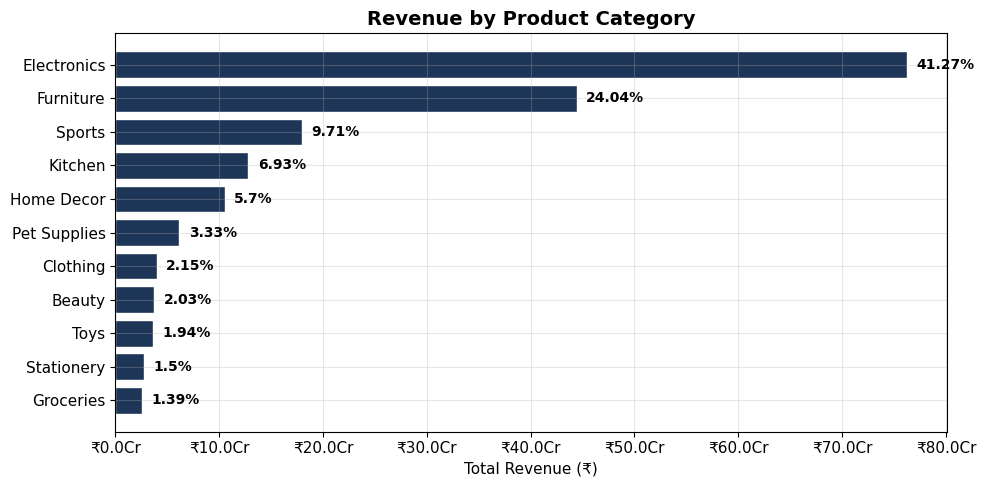

,category,revenue,revenue_pct
2,Electronics,762714537.98,41.27
3,Furniture,444312233.14,24.04
8,Sports,179345171.09,9.71
6,Kitchen,128148295.33,6.93
5,Home Decor,105308693.21,5.70
7,Pet Supplies,61578012.02,3.33
1,Clothing,39811939.74,2.15
0,Beauty,37496084.34,2.03
10,Toys,35920258.82,1.94
9,Stationery,27656054.66,1.50


In [10]:
# 6.1 Revenue by Category — with % contribution

category_revenue = (
    analytics_df.groupby('category', as_index=False)['revenue']
    .sum()
    .sort_values('revenue', ascending=True)
)
category_revenue['revenue_pct'] = (category_revenue['revenue'] / category_revenue['revenue'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(category_revenue['category'], category_revenue['revenue'], color='#1d3557', edgecolor='white')

for bar, pct in zip(bars, category_revenue['revenue_pct']):
    ax.text(bar.get_width() + total_revenue * 0.005, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10, fontweight='bold')

ax.set_title('Revenue by Product Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (₹)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e7:.1f}Cr'))
plt.tight_layout()
plt.show()

display(category_revenue.sort_values('revenue', ascending=False))

## 6.2 Seasonal Sales

Does demand shift meaningfully by season, and if so, should inventory levels move with it?

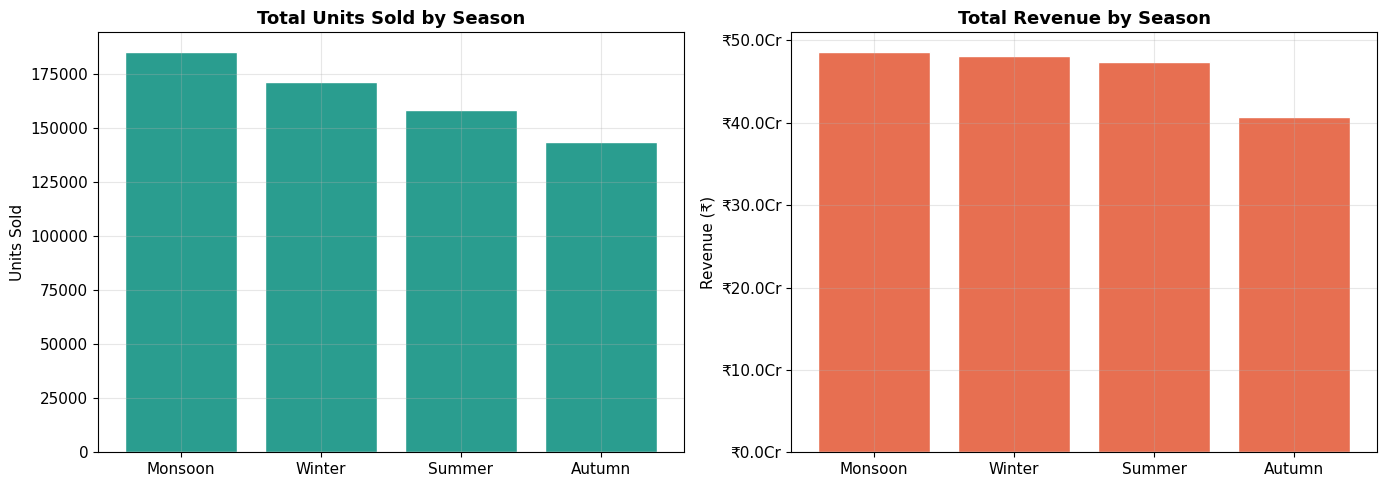

,season,units_sold,revenue
1,Monsoon,185159.00,485495928.43
3,Winter,171627.00,481091871.96
2,Summer,158531.00,474147825.65
0,Autumn,143796.00,407230268.92


In [11]:
# 6.2 Units Sold & Revenue by Season

season_stats = (
    analytics_df.groupby('season', as_index=False)
    .agg(units_sold=('units_sold', 'sum'), revenue=('revenue', 'sum'))
    .sort_values('revenue', ascending=False)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Units sold
ax1.bar(season_stats['season'], season_stats['units_sold'], color='#2a9d8f', edgecolor='white')
ax1.set_title('Total Units Sold by Season', fontsize=13, fontweight='bold')
ax1.set_ylabel('Units Sold')

# Revenue
ax2.bar(season_stats['season'], season_stats['revenue'], color='#e76f51', edgecolor='white')
ax2.set_title('Total Revenue by Season', fontsize=13, fontweight='bold')
ax2.set_ylabel('Revenue (₹)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e7:.1f}Cr'))

plt.tight_layout()
plt.show()

display(season_stats)

## 6.3 Supplier Scorecard

Who's reliable, who isn't, and who's worth a renegotiation conversation.

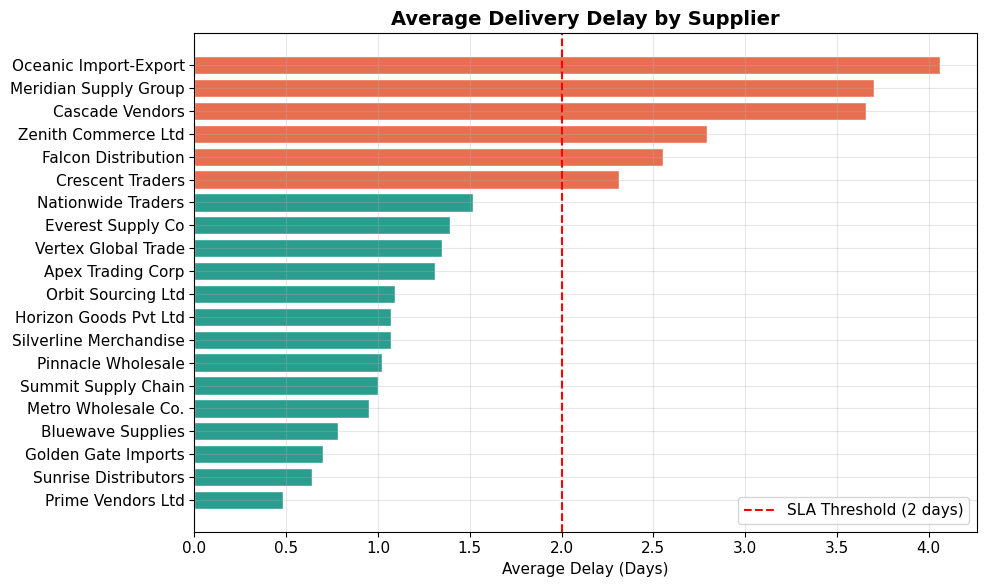

,supplier_name,avg_delay,on_time_pct,total_revenue,fill_rate
14,Prime Vendors Ltd,0.48,91.17,101591230.39,1.00
17,Sunrise Distributors,0.64,88.65,73659766.17,1.00
6,Golden Gate Imports,0.70,87.26,174717559.86,1.00
1,Bluewave Supplies,0.78,88.17,131121887.37,1.00
9,Metro Wholesale Co.,0.95,88.76,88218829.27,0.91
16,Summit Supply Chain,1.00,89.42,51963321.76,0.91
13,Pinnacle Wholesale,1.02,88.03,32830360.14,0.88
15,Silverline Merchandise,1.07,87.54,119664049.49,1.00
7,Horizon Goods Pvt Ltd,1.07,86.07,68133939.23,0.86
12,Orbit Sourcing Ltd,1.09,88.59,91598064.49,1.00


In [12]:
# 6.3 Supplier Performance Scorecard

supplier_perf = (
    analytics_df.groupby('supplier_name', as_index=False)
    .agg(
        avg_delay=('delivery_delay_days', 'mean'),
        on_time_pct=('delivery_delay_days', lambda x: (x <= 2).mean() * 100),
        units_received_sum=('units_received', 'sum'),
        units_ordered_sum=('units_ordered', 'sum'),
        total_revenue=('revenue', 'sum')
    )
)
# Same volume-weighted fill rate as elsewhere, not a mean of ratios.
supplier_perf['fill_rate'] = (
    supplier_perf['units_received_sum'] / supplier_perf['units_ordered_sum']
).clip(0, 1)
supplier_perf = (
    supplier_perf
    .drop(columns=['units_received_sum', 'units_ordered_sum'])
    .round(2)
    .sort_values('avg_delay', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2a9d8f' if d <= 2 else '#e76f51' for d in supplier_perf['avg_delay']]
ax.barh(supplier_perf['supplier_name'], supplier_perf['avg_delay'], color=colors, edgecolor='white')
ax.axvline(x=2, color='red', linestyle='--', label='SLA Threshold (2 days)')
ax.set_title('Average Delivery Delay by Supplier', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Delay (Days)')
ax.legend()
plt.tight_layout()
plt.show()

display(supplier_perf.head(10))

## 6.4 Do Promotions Actually Move Revenue?

Testing whether promo/holiday days show a real revenue lift, or whether what looks like a bump is just noise.

In [13]:
# 6.4 Promotional Impact — Independent t-test

promo_revenue = analytics_df.loc[analytics_df['holiday_promo_flag'] == 1, 'revenue']
normal_revenue = analytics_df.loc[analytics_df['holiday_promo_flag'] == 0, 'revenue']

t_stat, p_value = stats.ttest_ind(promo_revenue, normal_revenue, equal_var=False)

promo_vs_normal = pd.DataFrame({
    'Group': ['Promo/Holiday', 'Normal'],
    'Mean Revenue': [round(promo_revenue.mean(), 2), round(normal_revenue.mean(), 2)],
    'Median Revenue': [round(promo_revenue.median(), 2), round(normal_revenue.median(), 2)],
    'N Records': [len(promo_revenue), len(normal_revenue)]
})

print('=' * 55)
print('Promotional vs Normal Day Revenue Comparison')
print('=' * 55)
display(promo_vs_normal)

print(f'\nt-statistic : {t_stat:.4f}')
print(f'p-value     : {p_value:.6f}')

alpha = 0.05
if p_value < alpha:
    print(f'\nResult: ✅ Statistically significant (p < {alpha}) — promo/holiday days show a real revenue lift.')
else:
    print(f'\nResult: ⚠️ Not statistically significant (p >= {alpha}) — observed difference may be random variation.')

Promotional vs Normal Day Revenue Comparison


,Group,Mean Revenue,Median Revenue,N Records
0,Promo/Holiday,36368.35,7378.98,7633
1,Normal,37955.39,7414.76,41374



t-statistic : -1.1477
p-value     : 0.251096

Result: ⚠️ Not statistically significant (p >= 0.05) — observed difference may be random variation.


## 6.5 Weather Impact on Sales

Does weather meaningfully change what people buy, and is it worth factoring into inventory planning?

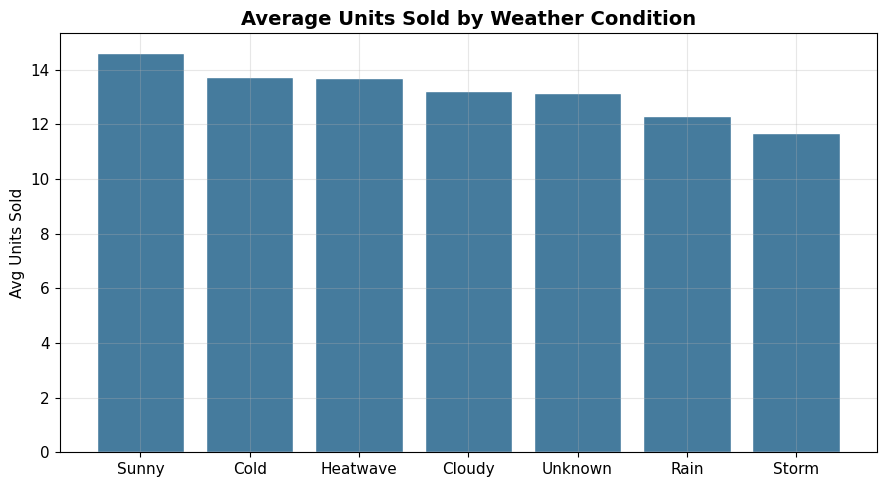

,weather,avg_units_sold,total_revenue,record_count
5,Sunny,14.60,603742478.10,13910
1,Cold,13.75,206070333.43,5512
2,Heatwave,13.68,126387415.26,2902
0,Cloudy,13.23,478029526.51,13184
6,Unknown,13.15,60845126.37,1466
3,Rain,12.32,311590039.19,9727
4,Storm,11.67,61300976.10,2306


In [14]:
# 6.5 Weather Impact on Units Sold

weather_impact = (
    analytics_df.groupby('weather', as_index=False)
    .agg(
        avg_units_sold=('units_sold', 'mean'),
        total_revenue=('revenue', 'sum'),
        record_count=('units_sold', 'count')
    )
    .round(2)
    .sort_values('avg_units_sold', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(weather_impact['weather'], weather_impact['avg_units_sold'], color='#457b9d', edgecolor='white')
ax.set_title('Average Units Sold by Weather Condition', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Units Sold')
plt.tight_layout()
plt.show()

display(weather_impact)

# 7. Trend Analysis

Looking at revenue and sales over time — seasonal patterns, growth trajectory, month-over-month and year-over-year swings.

## 7.1 Monthly Revenue, 2021–2024

How has revenue actually moved over four years, and is there a recurring seasonal shape to it?

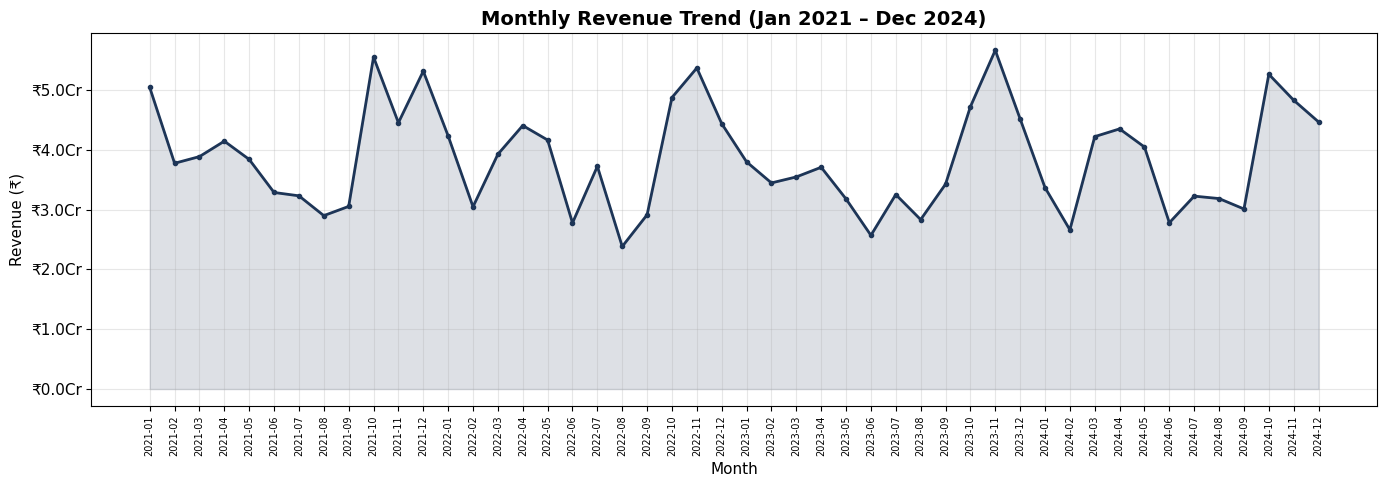

In [15]:
# 7.1 Monthly Revenue Trend

monthly_revenue = (
    analytics_df.groupby('year_month', as_index=False)
    .agg(revenue=('revenue', 'sum'), units_sold=('units_sold', 'sum'))
    .sort_values('year_month')
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_revenue['year_month'], monthly_revenue['revenue'], color='#1d3557', linewidth=2, marker='o', markersize=3)
ax.fill_between(monthly_revenue['year_month'], monthly_revenue['revenue'], alpha=0.15, color='#1d3557')
ax.set_title('Monthly Revenue Trend (Jan 2021 – Dec 2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e7:.1f}Cr'))
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

## 7.2 Year-over-Year and Month-over-Month Growth

Is the business actually growing, and which months are carrying (or dragging) that growth?

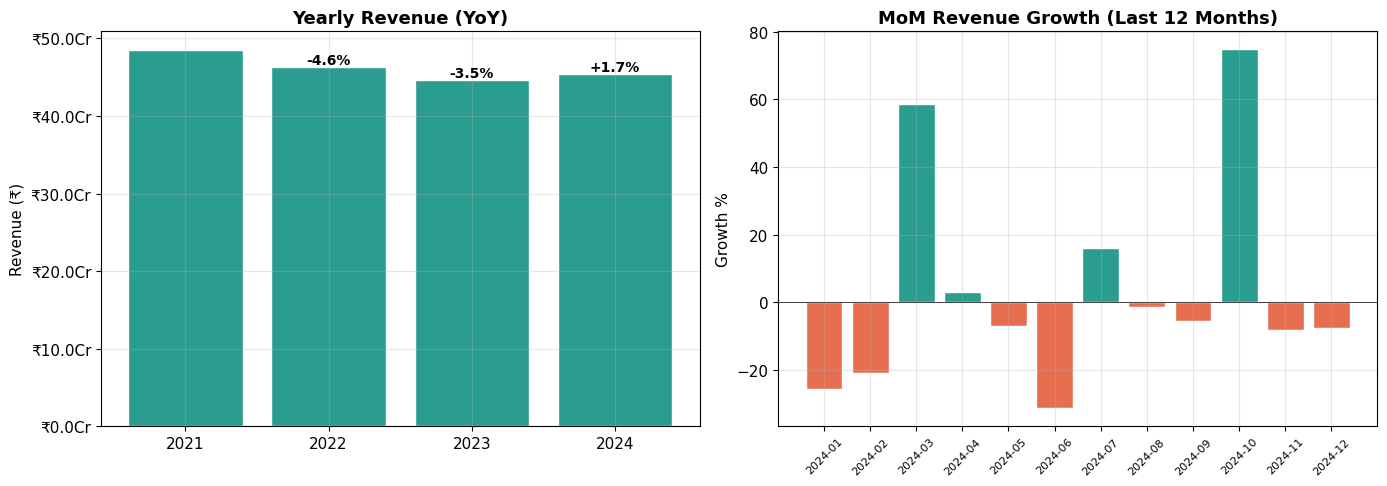

Yearly Revenue Summary:


,year,revenue,yoy_growth_pct
0,2021,484758654.67,NaN
1,2022,462536757.29,-4.58
2,2023,446597845.00,-3.45
3,2024,454072638.00,1.67


In [16]:
# 7.2 YoY and MoM Growth Analysis

# Yearly revenue
yearly_revenue = (
    analytics_df.groupby('year', as_index=False)['revenue']
    .sum()
    .sort_values('year')
)
yearly_revenue['yoy_growth_pct'] = yearly_revenue['revenue'].pct_change().round(4) * 100

# Monthly MoM
monthly_revenue['mom_growth_pct'] = monthly_revenue['revenue'].pct_change().round(4) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# YoY
bars = ax1.bar(yearly_revenue['year'].astype(str), yearly_revenue['revenue'], color='#2a9d8f', edgecolor='white')
ax1.set_title('Yearly Revenue (YoY)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Revenue (₹)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e7:.1f}Cr'))
for bar, growth in zip(bars, yearly_revenue['yoy_growth_pct']):
    if pd.notna(growth):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{growth:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# MoM (last 12 months)
last_12 = monthly_revenue.tail(12)
colors = ['#2a9d8f' if g > 0 else '#e76f51' for g in last_12['mom_growth_pct']]
ax2.bar(last_12['year_month'], last_12['mom_growth_pct'], color=colors, edgecolor='white')
ax2.set_title('MoM Revenue Growth (Last 12 Months)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Growth %')
ax2.axhline(y=0, color='black', linewidth=0.5)
plt.xticks(rotation=45, fontsize=8)

plt.tight_layout()
plt.show()

print('Yearly Revenue Summary:')
display(yearly_revenue)

# 8. Advanced Business Analytics

Moving past basic EDA into a couple of standard inventory classification techniques — the kind that show up in most retail ops playbooks.

---

## 8.1 ABC Classification (Pareto)

The classic 80/20 split, applied to products by revenue:
- **A** (top ~80% of revenue) — tight control, these can't afford to stock out
- **B** (next ~15%) — standard monitoring
- **C** (bottom ~5%) — not worth much attention

Nothing novel here, but it's the fastest way to tell an inventory manager where to focus.

ABC Classification Summary


,abc_class,product_count,total_revenue,revenue_pct
0,A,82,1475278034.38,79.83
1,B,149,280240892.98,15.16
2,C,179,92446967.60,5.00


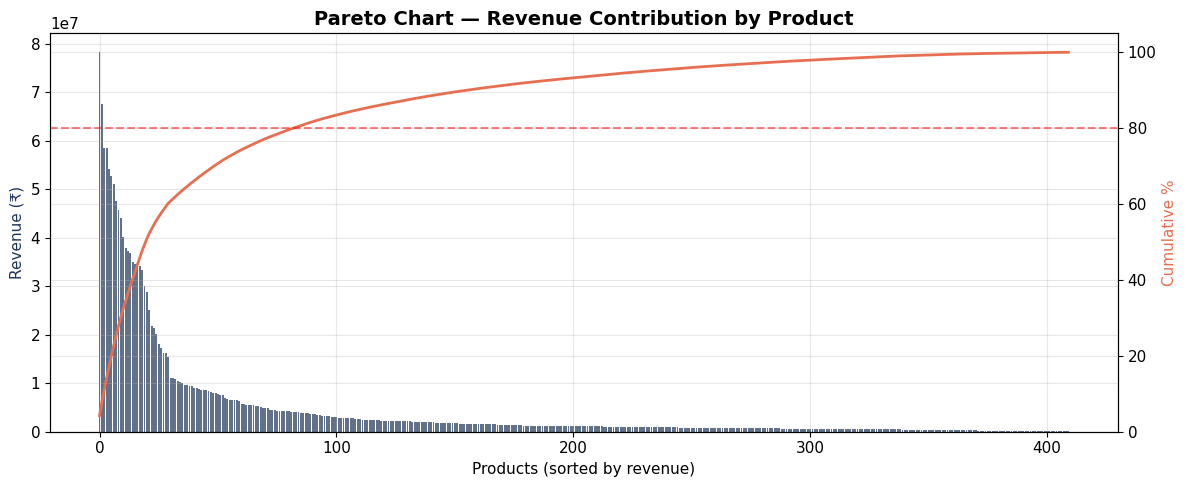


Top 10 Class A Products:


,product_id,product_name,category,revenue,cumulative_revenue,cumulative_pct,abc_class
0,ELE-P0031,Bluetooth Speaker Classic,Electronics,78243290.66,78243290.66,4.23,A
1,ELE-P0036,Air Conditioner Classic,Electronics,67561324.90,145804615.56,7.89,A
2,ELE-P0040,Power Bank Classic,Electronics,58550207.31,204354822.87,11.06,A
3,ELE-P0039,Smart Watch Classic,Electronics,58466075.53,262820898.40,14.22,A
4,ELE-P0030,Water Purifier Classic,Electronics,54227203.78,317048102.18,17.16,A
5,ELE-P0021,Air Conditioner Plus,Electronics,52671094.30,369719196.48,20.01,A
6,FUR-P0037,Wardrobe Mini,Furniture,51116979.28,420836175.76,22.77,A
7,ELE-P0023,Microwave Oven Plus,Electronics,47532871.52,468369047.28,25.35,A
8,ELE-P0022,Room Cooler Plus,Electronics,45720741.85,514089789.13,27.82,A
9,FUR-P0025,Dining Table Classic,Furniture,43973406.66,558063195.79,30.20,A


In [17]:
# 8.1 ABC Classification (Pareto / 80-20 Analysis)

abc_data = (
    analytics_df.groupby(['product_id', 'product_name', 'category'], as_index=False)['revenue']
    .sum()
    .sort_values('revenue', ascending=False)
    .reset_index(drop=True)
)

abc_data['cumulative_revenue'] = abc_data['revenue'].cumsum()
abc_data['cumulative_pct'] = (abc_data['cumulative_revenue'] / abc_data['revenue'].sum() * 100).round(2)

def assign_abc_class(cum_pct):
    if cum_pct <= 80:
        return 'A'
    elif cum_pct <= 95:
        return 'B'
    else:
        return 'C'

abc_data['abc_class'] = abc_data['cumulative_pct'].apply(assign_abc_class)

# Summary
abc_summary = (
    abc_data.groupby('abc_class')
    .agg(
        product_count=('product_id', 'count'),
        total_revenue=('revenue', 'sum'),
        revenue_pct=('revenue', lambda x: round(x.sum() / abc_data['revenue'].sum() * 100, 2))
    )
    .reset_index()
)

print('ABC Classification Summary')
print('=' * 50)
display(abc_summary)

# Pareto chart
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(range(len(abc_data)), abc_data['revenue'], color='#1d3557', alpha=0.7)
ax1.set_xlabel('Products (sorted by revenue)')
ax1.set_ylabel('Revenue (₹)', color='#1d3557')

ax2 = ax1.twinx()
ax2.plot(range(len(abc_data)), abc_data['cumulative_pct'], color='#e76f51', linewidth=2)
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
ax2.set_ylabel('Cumulative %', color='#e76f51')
ax2.set_ylim(0, 105)

ax1.set_title('Pareto Chart — Revenue Contribution by Product', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 10 Class A Products:')
display(abc_data[abc_data['abc_class'] == 'A'].head(10))

## 8.2 XYZ — Demand Variability

Same idea as ABC, but based on how volatile demand is (coefficient of variation) instead of revenue:
- **X** (CV ≤ 0.5) — steady, easy to forecast
- **Y** (0.5–1.0) — some swings, needs a buffer
- **Z** (CV > 1.0) — unpredictable, needs real safety stock

Cross this with ABC and you get a much more useful inventory strategy than either gives you alone.

In [18]:
# 8.2 XYZ Demand Variability Classification

xyz_data = (
    analytics_df.groupby('product_id')
    .agg(
        mean_demand=('units_sold', 'mean'),
        std_demand=('units_sold', 'std')
    )
)

xyz_data['cv'] = (xyz_data['std_demand'] / xyz_data['mean_demand']).round(2)
xyz_data['xyz_class'] = xyz_data['cv'].apply(
    lambda cv: 'X' if cv <= 0.5 else ('Y' if cv <= 1.0 else 'Z')
)

xyz_summary = (
    xyz_data.groupby('xyz_class')
    .agg(product_count=('cv', 'count'), avg_cv=('cv', 'mean'))
    .round(2)
    .reset_index()
)

print('XYZ Classification Summary')
print('=' * 40)
display(xyz_summary)

# ABC-XYZ Matrix
abc_xyz = abc_data[['product_id', 'abc_class']].merge(
    xyz_data[['xyz_class']].reset_index(), on='product_id', how='left'
)

matrix = pd.crosstab(abc_xyz['abc_class'], abc_xyz['xyz_class'], margins=True, margins_name='Total')
print('\nABC-XYZ Combined Matrix:')
display(matrix)

XYZ Classification Summary


,xyz_class,product_count,avg_cv
0,Y,357,0.86
1,Z,53,1.24



ABC-XYZ Combined Matrix:


xyz_class,Y,Z,Total
abc_class,,,
A,69,13,82
B,128,21,149
C,160,19,179
Total,357,53,410


## 8.3 Dead Stock and Slow Movers

Flagging products with turnover so low they're basically just sitting there tying up capital, plus the opposite case — fast movers that probably need a tighter reorder cycle.

Inventory Movement Classification


,Category,Product Count,Avg Turnover
0,Fast Movers (≥2.0),410,13.85
1,Slow Movers (0.5–2.0),0,0.00
2,Dead Stock (<0.5),0,0.00


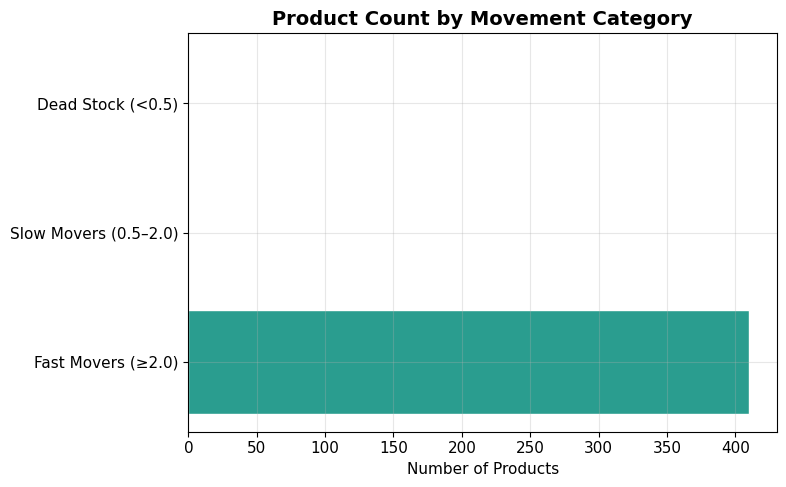


🔴 Dead Stock Products (0 total):


,product_name,category,turnover_ratio



🟢 Top 10 Fast-Moving Products:


,product_name,category,turnover_ratio
362,File Folder Pack Classic,Stationery,54.36
192,Biscuit Pack Classic,Groceries,42.29
318,Gym Gloves Plus,Sports,40.05
191,Instant Noodles Pack Classic,Groceries,38.69
255,Storage Container Set Classic,Kitchen,36.92
102,Electric Kettle Plus,Electronics,36.57
149,Dining Table Mini,Furniture,35.81
387,Slime Kit,Toys,35.48
85,Wireless Keyboard,Electronics,34.23
360,Sketch Pen Set Classic,Stationery,33.09


In [19]:
# 8.3 Inventory Turnover, Dead Stock, Fast/Slow Movers

turnover_data = (
    analytics_df.groupby(['product_id', 'product_name', 'category'], as_index=False)
    .agg(
        total_units_sold=('units_sold', 'sum'),
        avg_inventory=('inventory_level', 'mean')
    )
)
turnover_data['turnover_ratio'] = (turnover_data['total_units_sold'] / turnover_data['avg_inventory']).round(2)

# Dead stock: turnover < 0.5
dead_stock = turnover_data[turnover_data['turnover_ratio'] < 0.5].sort_values('turnover_ratio')

# Slow movers: 0.5 <= turnover < 2.0
slow_movers = turnover_data[(turnover_data['turnover_ratio'] >= 0.5) & (turnover_data['turnover_ratio'] < 2.0)]

# Fast movers: turnover >= 2.0
fast_movers = turnover_data[turnover_data['turnover_ratio'] >= 2.0].sort_values('turnover_ratio', ascending=False)

movement_summary = pd.DataFrame({
    'Category': ['Fast Movers (≥2.0)', 'Slow Movers (0.5–2.0)', 'Dead Stock (<0.5)'],
    'Product Count': [len(fast_movers), len(slow_movers), len(dead_stock)],
    'Avg Turnover': [
        round(fast_movers['turnover_ratio'].mean(), 2) if len(fast_movers) > 0 else 0,
        round(slow_movers['turnover_ratio'].mean(), 2) if len(slow_movers) > 0 else 0,
        round(dead_stock['turnover_ratio'].mean(), 2) if len(dead_stock) > 0 else 0
    ]
})

print('Inventory Movement Classification')
print('=' * 50)
display(movement_summary)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(movement_summary['Category'], movement_summary['Product Count'],
        color=['#2a9d8f', '#f4a261', '#e76f51'], edgecolor='white')
ax.set_title('Product Count by Movement Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Products')
plt.tight_layout()
plt.show()

print(f'\n🔴 Dead Stock Products ({len(dead_stock)} total):')
display(dead_stock[['product_name', 'category', 'turnover_ratio']].head(10))

print(f'\n🟢 Top 10 Fast-Moving Products:')
display(fast_movers[['product_name', 'category', 'turnover_ratio']].head(10))

## 8.4 Store Ranking

Which stores are pulling their weight on revenue, and which ones have stockout problems worth digging into?

Store Performance Ranking (Top 10)


,store_id,store_name,city,total_revenue,total_units_sold,stockout_rate,avg_inventory,revenue_rank
15,S016,Guwahati Mall Outlet,Guwahati,131032529.48,38177.50,0.60,134.22,1
10,S011,Surat Ring Road Store,Surat,120678794.20,37117.50,0.94,128.64,2
5,S006,Hyderabad Central Plaza,Hyderabad,118720215.35,34773.00,0.84,129.24,3
0,S001,Pune Central Store,Pune,114954651.44,30357.00,0.44,127.94,4
23,S024,Ranchi Mall Outlet,Ranchi,105873206.26,32149.50,0.65,130.51,5
24,S025,Raipur High Street Store,Raipur,87702511.25,23993.50,1.07,131.80,6
4,S005,Delhi Connaught Place Store,Delhi,87138288.58,34014.00,1.04,132.19,7
20,S021,Visakhapatnam Downtown Store,Visakhapatnam,86792216.82,28921.00,0.60,133.84,8
2,S003,Bengaluru Koramangala Store,Bengaluru,86752834.16,34443.50,0.48,132.35,9
16,S017,Chandigarh High Street Store,Chandigarh,77673833.18,30812.50,0.72,137.30,10



Bottom 5 Stores by Revenue:


,store_id,store_name,city,total_revenue,total_units_sold,stockout_rate,avg_inventory,revenue_rank
19,S020,Nashik Station Road Store,Nashik,46115958.33,25431.00,0.94,138.18,21
12,S013,Indore Downtown Store,Indore,43150324.75,19653.00,0.86,129.70,22
7,S008,Ahmedabad Mall Outlet,Ahmedabad,38541995.38,19285.00,0.79,130.65,23
3,S004,Chennai T Nagar Store,Chennai,37381534.31,19422.50,0.52,134.20,24
17,S018,Coimbatore City Centre Store,Coimbatore,37055641.61,12800.50,0.85,140.45,25


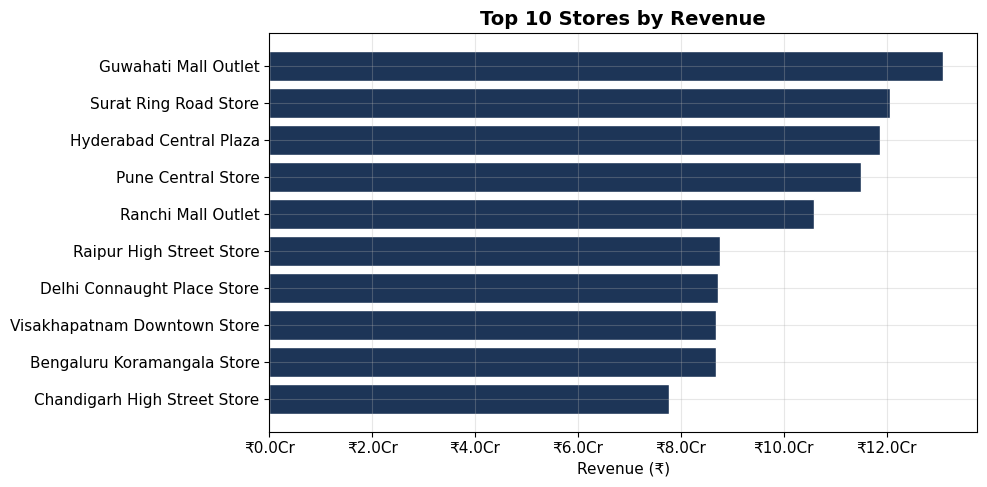

In [20]:
# 8.4 Store Performance Ranking

store_perf = (
    analytics_df.groupby(['store_id', 'store_name', 'city'], as_index=False)
    .agg(
        total_revenue=('revenue', 'sum'),
        total_units_sold=('units_sold', 'sum'),
        stockout_rate=('stockout_flag', lambda x: x.mean() * 100),
        avg_inventory=('inventory_level', 'mean')
    )
    .round(2)
)
store_perf['revenue_rank'] = store_perf['total_revenue'].rank(ascending=False, method='dense').astype(int)
store_perf = store_perf.sort_values('total_revenue', ascending=False)

print('Store Performance Ranking (Top 10)')
print('=' * 70)
display(store_perf.head(10))

print('\nBottom 5 Stores by Revenue:')
display(store_perf.tail(5))

# Top 10 revenue stores chart
fig, ax = plt.subplots(figsize=(10, 5))
top10 = store_perf.head(10)
ax.barh(top10['store_name'], top10['total_revenue'], color='#1d3557', edgecolor='white')
ax.set_title('Top 10 Stores by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (₹)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e7:.1f}Cr'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8.5 Warehouse Utilization

How well are warehouses actually being used, and are any of them consistently behind on deliveries or running into stockouts?

,warehouse_id,avg_inventory,total_stockouts,avg_delay,total_revenue,warehouse_name,capacity_units,utilization_pct
0,W01,134.37,78,1.49,476287382.49,North Distribution Center,60000,0.22
1,W02,133.04,80,1.46,417876602.02,South Distribution Center,55000,0.24
4,W05,133.87,79,1.55,315017679.87,West Distribution Center,65000,0.21
3,W04,128.99,35,1.52,212153457.95,East Distribution Center,48000,0.27
6,W07,129.59,56,1.57,208459954.57,Central-South Distribution Center,52000,0.25
5,W06,134.22,17,1.67,131032529.48,North-East Distribution Center,30000,0.45
2,W03,132.19,27,1.59,87138288.58,Central Distribution Center,70000,0.19


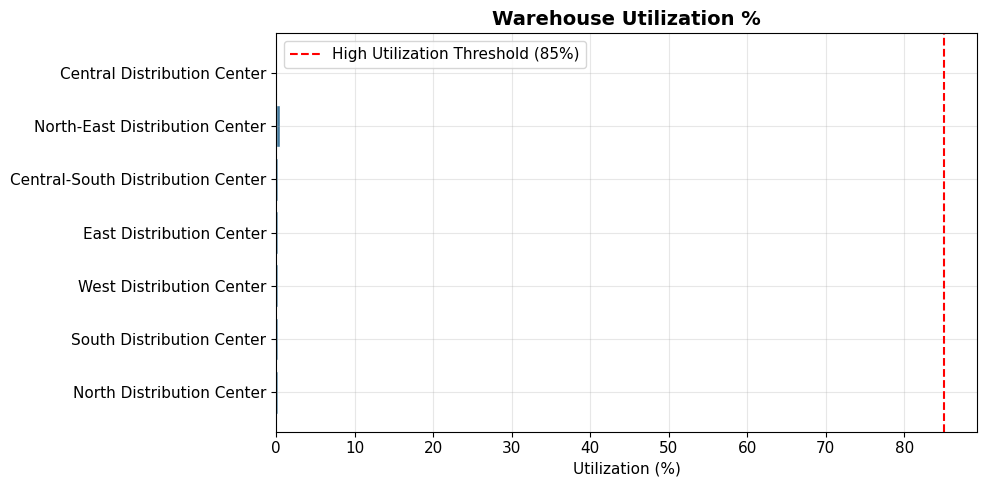

In [21]:
# 8.5 Warehouse Performance

wh_perf = (
    analytics_df.groupby('warehouse_id', as_index=False)
    .agg(
        avg_inventory=('inventory_level', 'mean'),
        total_stockouts=('stockout_flag', 'sum'),
        avg_delay=('delivery_delay_days', 'mean'),
        total_revenue=('revenue', 'sum')
    )
    .round(2)
)

# Merge with warehouse dimension for capacity
wh_perf = wh_perf.merge(warehouses_df[['warehouse_id', 'warehouse_name', 'capacity_units']], on='warehouse_id', how='left')
wh_perf['utilization_pct'] = (wh_perf['avg_inventory'] / wh_perf['capacity_units'] * 100).round(2)
wh_perf = wh_perf.sort_values('total_revenue', ascending=False)

display(wh_perf)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(wh_perf['warehouse_name'], wh_perf['utilization_pct'], color='#457b9d', edgecolor='white')
ax.axvline(x=85, color='red', linestyle='--', label='High Utilization Threshold (85%)')
ax.set_title('Warehouse Utilization %', fontsize=14, fontweight='bold')
ax.set_xlabel('Utilization (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 8.6 Correlation Check

A quick look at how the key numeric variables relate — does delivery delay actually track with stockouts? Does inventory level move with units sold the way you'd expect? Mostly a sanity check before drawing conclusions elsewhere.

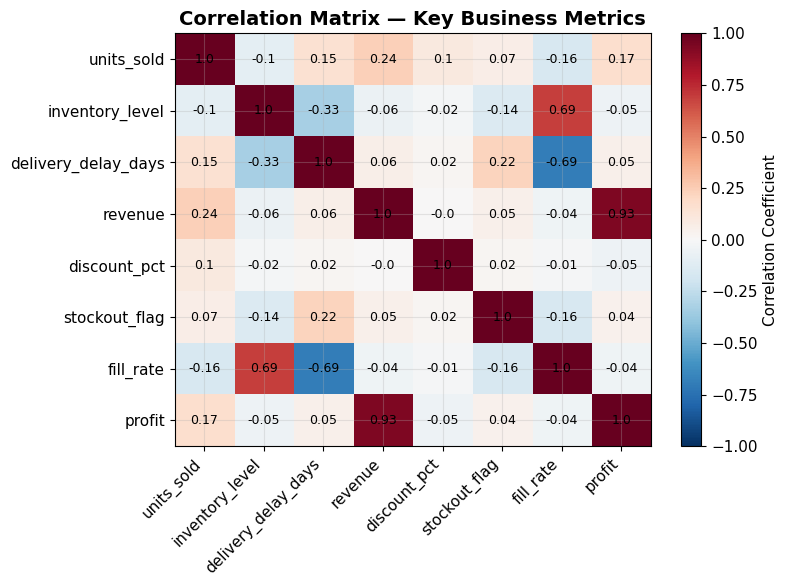

Key Correlations:
  Delivery Delay vs Stockout: 0.220
  Inventory Level vs Units Sold: -0.100
  Discount vs Revenue: -0.000
  Fill Rate vs Stockout: -0.160


In [22]:
# 8.6 Correlation Matrix

corr_cols = ['units_sold', 'inventory_level', 'delivery_delay_days', 'revenue',
             'discount_pct', 'stockout_flag', 'fill_rate', 'profit']

corr_matrix = analytics_df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, corr_matrix.iloc[i, j], ha='center', va='center', fontsize=9)

plt.colorbar(im, ax=ax, label='Correlation Coefficient')
ax.set_title('Correlation Matrix — Key Business Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key Correlations:')
print(f'  Delivery Delay vs Stockout: {corr_matrix.loc["delivery_delay_days", "stockout_flag"]:.3f}')
print(f'  Inventory Level vs Units Sold: {corr_matrix.loc["inventory_level", "units_sold"]:.3f}')
print(f'  Discount vs Revenue: {corr_matrix.loc["discount_pct", "revenue"]:.3f}')
print(f'  Fill Rate vs Stockout: {corr_matrix.loc["fill_rate", "stockout_flag"]:.3f}')

# 9. Root Cause Analysis

EDA tells you what's happening. This tries to get at why — specifically, connecting supplier delays to stockouts and putting an actual number on what that costs in lost revenue.

## 9.1 Does Delivery Delay Actually Cause Stockouts?

And if so, how much worse do things get as delays grow?

Delivery Delay Impact on Stockout & Fill Rate


,delivery_delay_days,stockout_rate,record_count,average_fill_rate
0,0–1 days,0.02,43114,4090.26
1,2–3 days,4.55,220,0.52
2,4–5 days,6.51,476,0.71
3,6+ days,5.50,2635,0.57


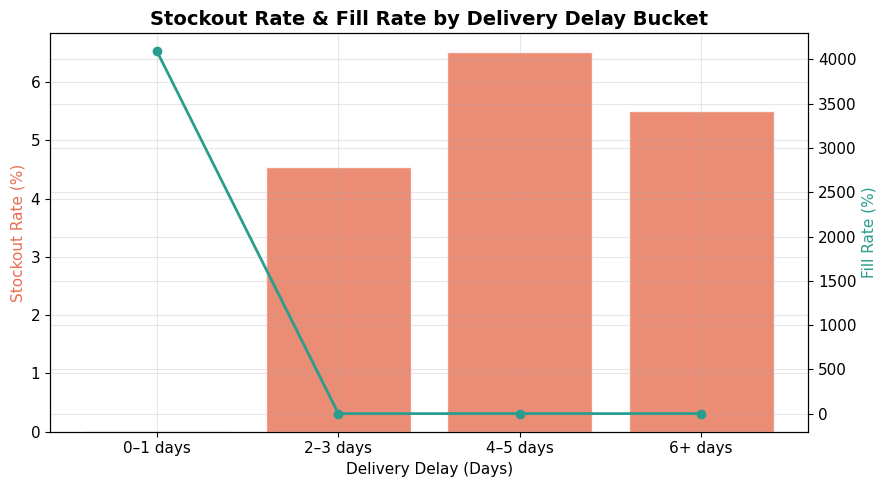

In [23]:
# 9.1 Delivery Delay vs Stockout & Fill Rate

delay_analysis = (
    analytics_df
    .groupby(
        pd.cut(analytics_df['delivery_delay_days'], bins=[-1, 1, 3, 5, 10],
               labels=['0–1 days', '2–3 days', '4–5 days', '6+ days']),
        observed=False
    )
    .agg(
        stockout_rate=('stockout_flag', lambda x: x.mean() * 100),
        units_received_sum=('units_received', 'sum'),
        units_ordered_sum=('units_ordered', 'sum'),
        record_count=('units_sold', 'count')
    )
    .reset_index()
)
# Volume-weighted again, same reasoning as the KPI summary above.
delay_analysis['average_fill_rate'] = (
    (delay_analysis['units_received_sum'] / delay_analysis['units_ordered_sum']) * 100
).round(2)
delay_analysis['stockout_rate'] = delay_analysis['stockout_rate'].round(2)
delay_analysis = delay_analysis.drop(columns=['units_received_sum', 'units_ordered_sum'])
delay_analysis['delivery_delay_days'] = delay_analysis['delivery_delay_days'].astype(str)

print('Delivery Delay Impact on Stockout & Fill Rate')
print('=' * 60)
display(delay_analysis)

fig, ax1 = plt.subplots(figsize=(9, 5))
x = range(len(delay_analysis))
ax1.bar(x, delay_analysis['stockout_rate'], color='#e76f51', alpha=0.8, label='Stockout Rate %', edgecolor='white')
ax1.set_ylabel('Stockout Rate (%)', color='#e76f51')
ax1.set_xticks(x)
ax1.set_xticklabels(delay_analysis['delivery_delay_days'])

ax2 = ax1.twinx()
ax2.plot(x, delay_analysis['average_fill_rate'], color='#2a9d8f', marker='o', linewidth=2, label='Fill Rate %')
ax2.set_ylabel('Fill Rate (%)', color='#2a9d8f')

ax1.set_title('Stockout Rate & Fill Rate by Delivery Delay Bucket', fontsize=14, fontweight='bold')
ax1.set_xlabel('Delivery Delay (Days)')
plt.tight_layout()
plt.show()

## 9.2 What Do Stockouts Actually Cost?

The data doesn't give us lost sales directly, so this is an estimate, not a measurement. The approach:
1. Get the average revenue per unit on non-stockout days, per product
2. Use that to estimate the sales likely lost on stockout days
3. Multiply through and add it up across products

Treat this as a reasonable approximation, not a precise figure.

In [24]:
# 9.2 Estimated Revenue Impact of Stockouts

current_stockout_rate = analytics_df['stockout_flag'].mean() * 100

# Average units sold with and without stockouts (per product)
sales_comparison = (
    analytics_df.groupby(['product_id', 'stockout_flag'])['units_sold']
    .mean()
    .unstack(fill_value=np.nan)
)
sales_comparison.columns = ['avg_units_no_stockout', 'avg_units_stockout']
sales_comparison = sales_comparison.dropna()

# Average selling price per product
average_price = analytics_df.groupby('product_id')['unit_price_txn'].mean()

impact_analysis = sales_comparison.join(average_price.rename('average_unit_price'))

# Estimated lost units per stockout day
impact_analysis['estimated_units_lost'] = (
    impact_analysis['avg_units_no_stockout'] - impact_analysis['avg_units_stockout']
).clip(lower=0)

# Estimated lost revenue per stockout day
impact_analysis['estimated_revenue_lost_per_day'] = (
    impact_analysis['estimated_units_lost'] * impact_analysis['average_unit_price']
)

# Total stockout days per product
stockout_days = analytics_df.groupby('product_id')['stockout_flag'].sum()
impact_analysis = impact_analysis.join(stockout_days.rename('stockout_days'))

# Total estimated revenue loss
impact_analysis['estimated_total_revenue_lost'] = (
    impact_analysis['estimated_revenue_lost_per_day'] * impact_analysis['stockout_days']
)

total_estimated_loss = impact_analysis['estimated_total_revenue_lost'].sum()

print('=' * 60)
print('Estimated Revenue Impact of Stockouts')
print('=' * 60)
print(f'Current Stockout Rate: {current_stockout_rate:.2f}%')
print(f'Total Stockout Days: {int(analytics_df["stockout_flag"].sum()):,}')
print(f'Estimated Total Revenue Lost: ₹{total_estimated_loss:,.0f}')
print(f'Estimated Revenue Lost as % of Total Revenue: {(total_estimated_loss / analytics_df["revenue"].sum() * 100):.2f}%')

print(f'\nTop 10 Products by Estimated Revenue Loss:')
display(
    impact_analysis.sort_values('estimated_total_revenue_lost', ascending=False).head(10)
)

Estimated Revenue Impact of Stockouts
Current Stockout Rate: 0.76%
Total Stockout Days: 372
Estimated Total Revenue Lost: ₹1,678,763
Estimated Revenue Lost as % of Total Revenue: 0.09%

Top 10 Products by Estimated Revenue Loss:


,avg_units_no_stockout,avg_units_stockout,average_unit_price,estimated_units_lost,estimated_revenue_lost_per_day,stockout_days,estimated_total_revenue_lost
product_id,,,,,,,
FUR-P0036,13.24,5.75,20537.70,7.49,153820.55,4,615282.21
ELE-P0023,16.62,13.00,22994.86,3.62,83333.39,3,250000.16
HOM-P0023,12.15,6.00,1738.54,6.15,10694.68,8,85557.46
SPO-P0025,9.69,4.33,5115.95,5.36,27402.68,3,82208.04
SPO-P0028,15.66,10.50,4429.53,5.16,22840.84,2,45681.68
KIT-P0024,14.92,0.00,3010.08,14.92,44919.58,1,44919.58
FUR-P0028,11.86,7.00,8637.39,4.86,41976.09,1,41976.09
HOM-P0017,12.96,0.00,2811.90,12.96,36454.32,1,36454.32
FUR-P0032,11.41,0.00,2950.90,11.41,33667.06,1,33667.06


# 10. Rule-Based Recommendations

A set of straightforward business rules — not machine learning — that flag which products need reordering and how urgently, based on everything calculated above.

## 10.1 Reorder Recommendations

Products whose current inventory has dropped below their reorder point, with urgency bumped up if the supplier has a track record of long delays.

In [25]:
# 10.1 Reorder Recommendation Engine

# Latest inventory status for each Store–Product combination
latest_inventory = (
    analytics_df
    .sort_values('date')
    .groupby(['store_id', 'product_id'], as_index=False)
    .tail(1)
    .copy()
)

# Products below reorder point
reorder_report = latest_inventory[
    latest_inventory['inventory_level'] < latest_inventory['reorder_point']
].copy()

# Inventory gap
reorder_report['gap_to_reorder_point'] = (
    reorder_report['reorder_point'] - reorder_report['inventory_level']
)

# Urgency classification
reorder_report['urgency'] = np.select(
    [
        (reorder_report['gap_to_reorder_point'] > reorder_report['reorder_point'] * 0.5) &
        (reorder_report['delivery_delay_days'] > 5),
        reorder_report['delivery_delay_days'] > 5,
        reorder_report['gap_to_reorder_point'] > reorder_report['reorder_point'] * 0.5
    ],
    ['🔴 Critical — Expedite + Emergency Stock', '🟠 High — Expedite Supplier Follow-up', '🟡 Medium — Reorder Now'],
    default='🟢 Low — Standard Reorder'
)

reorder_report['recommendation'] = np.where(
    reorder_report['delivery_delay_days'] > 5,
    'Reorder immediately + Expedite supplier follow-up',
    'Reorder immediately'
)

print(f'Total products needing reorder: {len(reorder_report)}')
print(f'Critical urgency: {(reorder_report["urgency"].str.contains("Critical")).sum()}')
print(f'High urgency: {(reorder_report["urgency"].str.contains("High")).sum()}')
print()
display(
    reorder_report[
        ['store_name', 'product_name', 'inventory_level', 'reorder_point',
         'gap_to_reorder_point', 'urgency', 'recommendation']
    ]
    .sort_values('gap_to_reorder_point', ascending=False)
    .head(20)
)

Total products needing reorder: 583
Critical urgency: 104
High urgency: 390



,store_name,product_name,inventory_level,reorder_point,gap_to_reorder_point,urgency,recommendation
46684,Chennai T Nagar Store,Brown Bread,0.00,88,88.00,🟡 Medium — Reorder Now,Reorder immediately
46656,Delhi Connaught Place Store,Scented Candle Pack Plus,0.00,85,85.00,🔴 Critical — Expedite + Emergency Stock,Reorder immediately + Expedite supplier follow-up
42981,Ludhiana Central Plaza,Milk Powder 500g,8.00,86,78.00,🔴 Critical — Expedite + Emergency Stock,Reorder immediately + Expedite supplier follow-up
46399,Ranchi Mall Outlet,Hair Dryer,9.00,75,66.00,🔴 Critical — Expedite + Emergency Stock,Reorder immediately + Expedite supplier follow-up
46438,Guwahati Mall Outlet,Mirror Frame Classic,0.00,65,65.00,🔴 Critical — Expedite + Emergency Stock,Reorder immediately + Expedite supplier follow-up
48228,Kolkata MG Road Store,Dining Table Classic,0.00,62,62.00,🟡 Medium — Reorder Now,Reorder immediately
46927,Nashik Station Road Store,Shampoo 500ml Classic,0.00,61,61.00,🔴 Critical — Expedite + Emergency Stock,Reorder immediately + Expedite supplier follow-up
48739,Jaipur High Street Store,Building Blocks Mini,4.00,65,61.00,🔴 Critical — Expedite + Emergency Stock,Reorder immediately + Expedite supplier follow-up
46626,Surat Ring Road Store,Kurta Set Classic,0.00,60,60.00,🔴 Critical — Expedite + Emergency Stock,Reorder immediately + Expedite supplier follow-up
46461,Ahmedabad Mall Outlet,Kurta Set Classic,0.00,60,60.00,🟡 Medium — Reorder Now,Reorder immediately


# 11. Exporting for the Dashboard

Writing out the analysis results as CSVs, aggregated to whatever granularity makes sense for Tableau/Excel — no further processing should be needed on the reporting side.

In [26]:
# 11. Export Dashboard-Ready Datasets
exports = {}

# 1. Monthly KPI Summary
exports['monthly_kpi'] = (
    analytics_df.groupby('year_month', as_index=False)
    .agg(
        total_revenue=('revenue', 'sum'),
        total_units_sold=('units_sold', 'sum'),
        total_profit=('profit', 'sum'),
        stockout_rate_pct=('stockout_flag', lambda x: round(x.mean() * 100, 2)),
        units_received_sum=('units_received', 'sum'),
        units_ordered_sum=('units_ordered', 'sum')
    )
)
# Volume-weighted (sum received / sum ordered), not a mean of per-row ratios —
# rows with units_ordered=0 turn into NaN and get silently dropped from a plain
# .mean(), which was skewing this low. Matches the SQL definition now
# (SQL_data/monthly_kpi_summary.csv uses SUM(received)/SUM(ordered)).
exports['monthly_kpi']['avg_fill_rate_pct'] = (
    (exports['monthly_kpi']['units_received_sum'] / exports['monthly_kpi']['units_ordered_sum']) * 100
).round(2)
exports['monthly_kpi'] = (
    exports['monthly_kpi']
    .drop(columns=['units_received_sum', 'units_ordered_sum'])
    .sort_values('year_month')
)

# 2. Category Performance
exports['category_performance'] = (
    analytics_df.groupby('category', as_index=False)
    .agg(
        total_revenue=('revenue', 'sum'),
        total_profit=('profit', 'sum'),
        total_units_sold=('units_sold', 'sum'),
        stockout_rate_pct=('stockout_flag', lambda x: round(x.mean() * 100, 2)),
        avg_inventory=('inventory_level', 'mean')
    )
    .round(2)
    .sort_values('total_revenue', ascending=False)
)

# 3. Store Performance
exports['store_performance'] = store_perf.copy()

# 4. Supplier Performance
exports['supplier_performance'] = supplier_perf.copy()

# 5. ABC Classification
exports['abc_classification'] = abc_data[
    ['product_id', 'product_name', 'category', 'revenue', 'cumulative_pct', 'abc_class']
]

# 6. Inventory Turnover
exports['inventory_turnover'] = turnover_data.copy()

# 7. Reorder Recommendations
exports['reorder_recommendations'] = reorder_report[
    ['store_name', 'product_name', 'category', 'inventory_level', 'reorder_point',
     'gap_to_reorder_point', 'urgency', 'recommendation']
].sort_values('gap_to_reorder_point', ascending=False)

# 8. Stockout Revenue Impact
exports['stockout_revenue_impact'] = (
    impact_analysis
    .sort_values('estimated_total_revenue_lost', ascending=False)
    .reset_index()
)

# Save all exports
from pathlib import Path

# Relative to wherever this is checked out — was a hardcoded Windows path before,
# which also meant it only worked on one machine and leaked a username.
PROJECT_DIR = Path.cwd()
EXPORT_DIR = PROJECT_DIR / "Clean Data"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

for name, df in exports.items():
    filepath = EXPORT_DIR / f"{name}.csv"
    df.to_csv(filepath, index=False)
    print(f"✓ {name}.csv exported ({len(df)} rows)")

print("\n" + "="*60)
print("All dashboard datasets exported successfully!")
print(f"Location: {EXPORT_DIR}")
print("="*60)

✓ monthly_kpi.csv exported (48 rows)
✓ category_performance.csv exported (11 rows)
✓ store_performance.csv exported (25 rows)
✓ supplier_performance.csv exported (20 rows)
✓ abc_classification.csv exported (410 rows)
✓ inventory_turnover.csv exported (410 rows)
✓ reorder_recommendations.csv exported (583 rows)
✓ stockout_revenue_impact.csv exported (163 rows)

All dashboard datasets exported successfully!
Location: /home/claude/project/Retail Inventory & Supply Chain Performance Analytics/Clean Data


# 12. Executive Summary

**~50,000 transactions, 4 years (Jan 2021 – Dec 2024), 25 stores, 410 products, 20 suppliers.**

### Key findings

| # | Finding | So what |
|---|---------|---------|
| 1 | Electronics drives the largest share of revenue | Prioritize inventory investment and reorder-point review here |
| 2 | Supplier delivery delays average 0.48–4.06 days depending on the supplier | Clear list of who to renegotiate with or replace |
| 3 | Stockout rate jumps from ~0.02% (0–1 day delay) to 4.55–6.51% (2+ days) | Supplier lead-time variability is a real, measurable driver of stockouts |
| 4 | ~20% of products (Class A) drive 80% of revenue | Focus inventory control there first |
| 5 | Some products have turnover under 0.5 — capital just sitting in the warehouse | Worth discounting or liquidating |
| 6 | Promo/holiday revenue lift isn't statistically significant at the aggregate level | Worth checking at category/product level instead of treating every promo the same |
| 7 | Stockout revenue loss is estimable, even if not exact | Gives a rough business case for safety stock investment |

### What this notebook actually did

Data quality checks, a logged cleaning pipeline, KPI calculations, ABC/XYZ classification, turnover and dead-stock detection, seasonal/MoM/YoY trend analysis, a correlation check, a t-test on promo impact, a rule-based reorder engine, and a stockout revenue estimate.

None of this needed anything fancier than pandas and some basic stats — which is kind of the point. Most of the value here came from getting the cleaning and the definitions right, not from the modeling.

# 13. Recommendations

| # | Recommendation | Priority | Why |
|---|----------------|----------|-----|
| 1 | Increase safety stock for Class A products with high stockout rates | High | These are the products actually losing revenue when they run out |
| 2 | Renegotiate or replace suppliers averaging over 3 days delay | High | Directly improves fill rate |
| 3 | Liquidate dead stock (turnover < 0.5) | Medium | Frees up capital and warehouse space |
| 4 | Apply an ABC-XYZ policy — tight control on AX, loose review on CZ | High | Better return on inventory management effort |
| 5 | Set a 2-day SLA on supplier delivery, with penalty clauses | Medium | Forces accountability instead of just tracking it |
| 6 | Rebalance inventory for stores with high stockouts but only moderate demand | Medium | Fixes a distribution problem, not a demand problem |
| 7 | Review reorder points seasonally, especially before Summer/Winter peaks | Medium | Keeps inventory aligned with actual demand shape |
| 8 | Evaluate promotions per category/product instead of one blanket calendar event | Low | Some promos are clearly working better than others |
| 9 | Watch warehouses running above ~85% utilization | Medium | Early warning before capacity becomes an actual problem |
| 10 | Turn this into a standing Tableau/Excel dashboard | High | So this doesn't stay a one-off notebook |

# 14. Assumptions & Limitations

### Assumptions
- Profit is estimated from each product's unit_cost — actual costs likely varied over time with supplier pricing changes.
- Stockout revenue loss is a business estimate based on historical average sales, not a measured figure.
- Reorder recommendations follow fixed business rules; they're meant to support decisions, not forecast demand.
- Inventory turnover uses the average inventory level per product over the whole period.
- ABC uses the standard 80/15/5 revenue split; XYZ uses CV thresholds of 0.5 and 1.0 — both are common conventions, not something derived from this dataset specifically.

### Limitations
- This is historical data only — no forward-looking demand signal.
- No customer-level behavior in the source data.
- Transportation costs, changing supplier pricing, and warehouse operating costs aren't factored in.
- The recommendation engine is rules-based, not predictive.
- Weather and season are observational, not controlled, so any causal claim here is weak at best.
- Read everything in this notebook as decision support, not a precise operational forecast.